# Week 7 & 8 - Dataset Preparation

This notebook demonstrates how to prepare facial images for the Face Aging project. It covers uploading an image, loading a face dataset, preprocessing images, and preparing them for the age progression model.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

## Step 1: Upload a Face Image

Upload a clear facial image that will later be used for age progression.

In [2]:
uploaded = files.upload()0

Saving IMG_5772.PNG to IMG_5772.PNG


In [3]:
image_name = list(uploaded.keys())[0]

print("Uploaded Image:", image_name)

Uploaded Image: IMG_5772.PNG


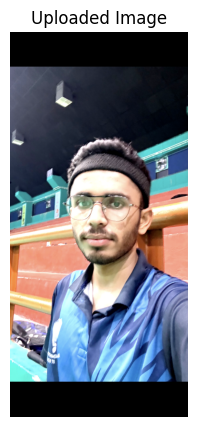

In [4]:
image = Image.open(image_name)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

## Step 2: Read the Image using OpenCV

In [5]:
image_cv = cv2.imread(image_name)

print("Image Shape:", image_cv.shape)

Image Shape: (2868, 1320, 3)


## Step 3: Convert BGR to RGB

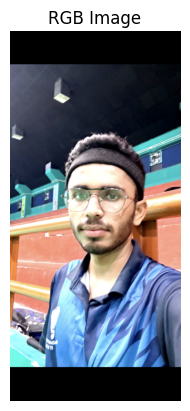

In [6]:
image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.title("RGB Image")
plt.show()

## Step 4: Resize the Image

Most face aging models require images of a fixed size.

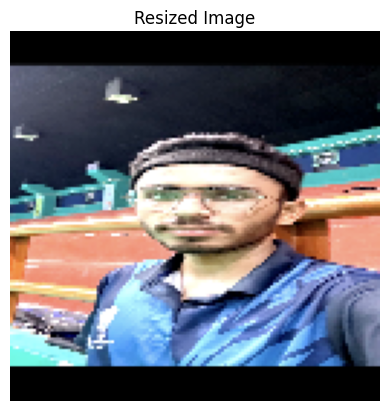

In [7]:
resized = cv2.resize(image_rgb, (128,128))

plt.imshow(resized)
plt.axis("off")
plt.title("Resized Image")
plt.show()

## Step 5: Normalize Pixel Values

Normalize pixel values between 0 and 1 before feeding the image to the model.

In [8]:
normalized = resized / 255.0

print("Minimum Pixel Value:", normalized.min())
print("Maximum Pixel Value:", normalized.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


## Step 6: Convert Image to NumPy Array

In [9]:
image_array = np.array(normalized)

print("Shape:", image_array.shape)
print("Data Type:", image_array.dtype)

Shape: (128, 128, 3)
Data Type: float64


## Step 7: Understanding the Face Dataset

The Face Aging project commonly uses datasets such as:

- UTKFace
- CelebA

These datasets contain face images along with age labels, making them suitable for training and evaluating age progression models.

In [10]:
datasets = [
    "UTKFace",
    "CelebA"
]

for dataset in datasets:
    print(dataset)

UTKFace
CelebA


## Step 8: Display Sample Dataset Information

In [11]:
dataset_info = {
    "UTKFace": "Face images with age, gender, and ethnicity labels.",
    "CelebA": "Large-scale celebrity face dataset with attribute annotations."
}

for name, description in dataset_info.items():
    print(f"{name}: {description}")

UTKFace: Face images with age, gender, and ethnicity labels.
CelebA: Large-scale celebrity face dataset with attribute annotations.


## Step 9: Save the Preprocessed Image

In [12]:
output_image = (normalized * 255).astype(np.uint8)

Image.fromarray(output_image).save("preprocessed_face.png")

print("Preprocessed image saved successfully.")

Preprocessed image saved successfully.


## Summary

In this notebook, we:

- Uploaded a face image.
- Loaded and displayed the image.
- Converted it to RGB.
- Resized the image.
- Normalized pixel values.
- Converted it to a NumPy array.
- Learned about the UTKFace and CelebA datasets.
- Saved the preprocessed image for use in the face aging model.